In [20]:
import sys
!{sys.executable} -m pip install xgboost
import xgboost
print(xgboost.__version__)

3.2.0


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    recall_score, precision_score, roc_auc_score,
    roc_curve, classification_report, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

from xgboost import XGBClassifier

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [22]:
df = pd.read_csv('cybersecurity_intrusion_data.csv')
df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.98,DES,0.61,1,Edge,0,1
1,SID_00002,472,TCP,3,1558.00,DES,0.30,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.04,DES,0.74,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.25,DES,0.12,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.54,AES,0.05,1,Firefox,0,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [24]:
df = df.drop(['session_id', 'encryption_used'], axis=1)

In [25]:
df.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.00,9537.00,9537.00,9537.00,9537.00,9537.00,9537.00
mean,500.43,4.03,792.75,0.33,1.52,0.15,0.45
std,198.38,1.96,786.56,0.18,1.03,0.36,0.50
min,64.00,1.00,0.50,0.00,0.00,0.00,0.00
25%,365.00,3.00,231.95,0.19,1.00,0.00,0.00
50%,499.00,4.00,556.28,0.31,1.00,0.00,0.00
75%,635.00,5.00,1105.38,0.45,2.00,0.00,1.00
max,1285.00,13.00,7190.39,0.92,5.00,1.00,1.00


In [26]:
print('Null values:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Null values:
network_packet_size    0
protocol_type          0
login_attempts         0
session_duration       0
ip_reputation_score    0
failed_logins          0
browser_type           0
unusual_time_access    0
attack_detected        0
dtype: int64

Duplicate rows: 0


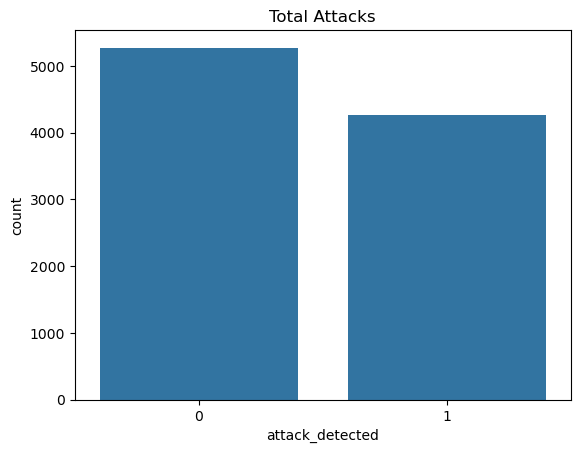

In [27]:
sns.countplot(x='attack_detected', data=df)
plt.title('Total Attacks')
plt.show()

In [28]:
le = LabelEncoder()
df['protocol_type'] = le.fit_transform(df['protocol_type'])
df['browser_type']  = le.fit_transform(df['browser_type'])
df.head()

,network_packet_size,protocol_type,login_attempts,session_duration,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,1,4,492.98,0.61,1,1,0,1
1,472,1,3,1558.00,0.30,0,2,0,0
2,629,1,3,75.04,0.74,2,0,0,1
3,804,2,4,601.25,0.12,0,4,0,1
4,453,1,5,532.54,0.05,1,2,0,0


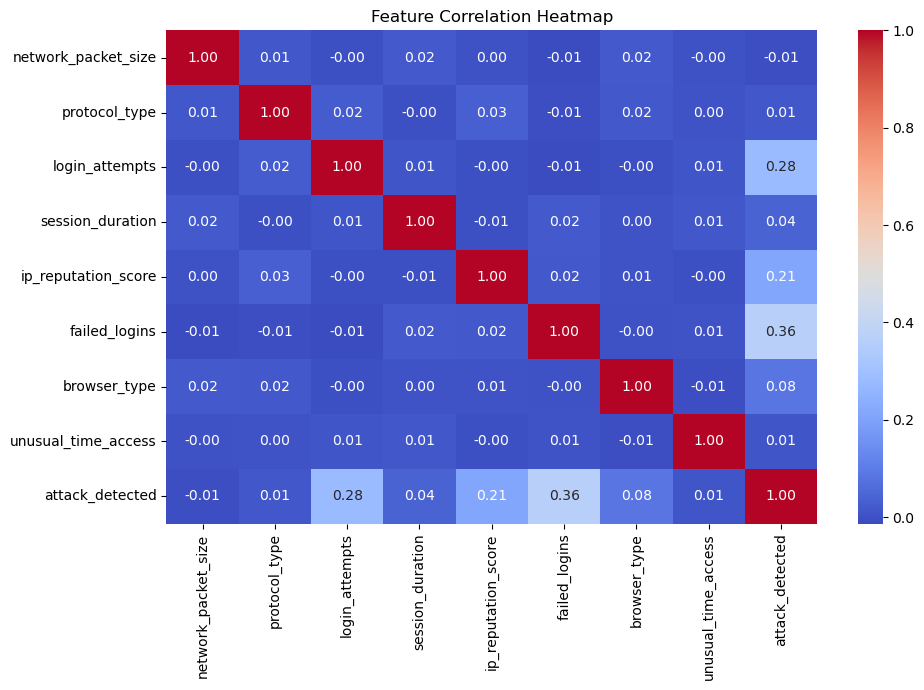

In [29]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

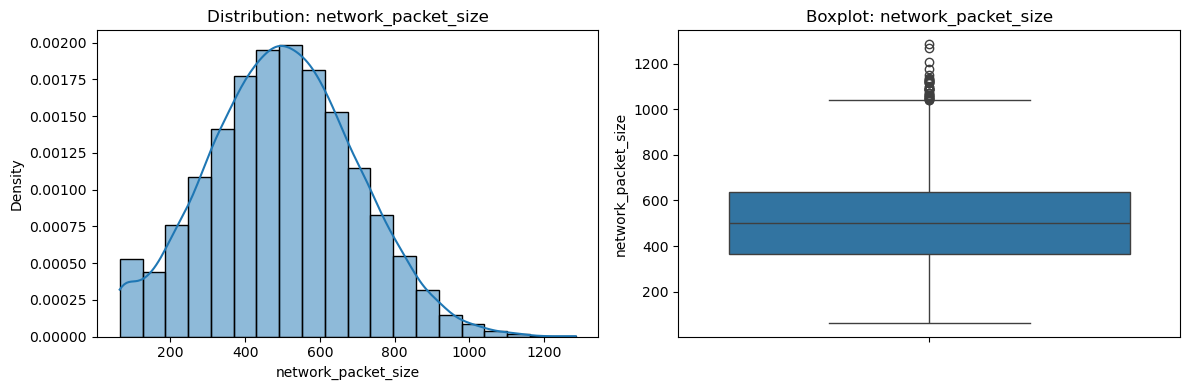

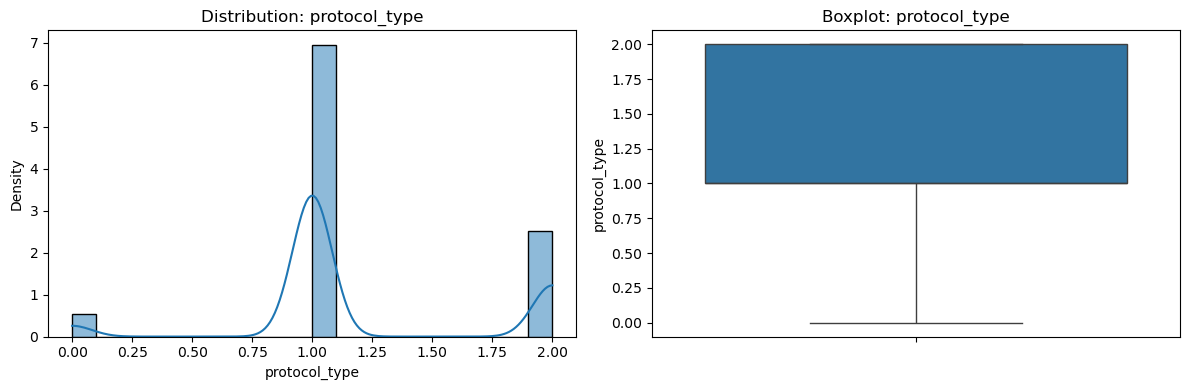

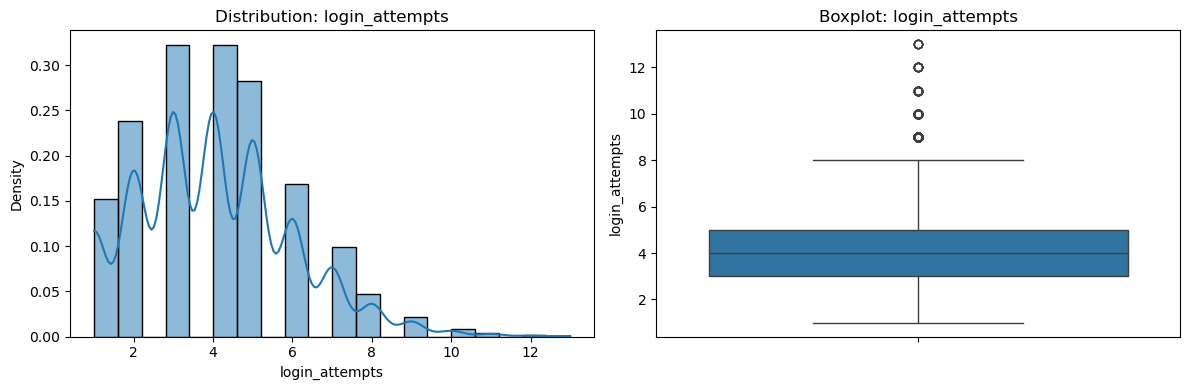

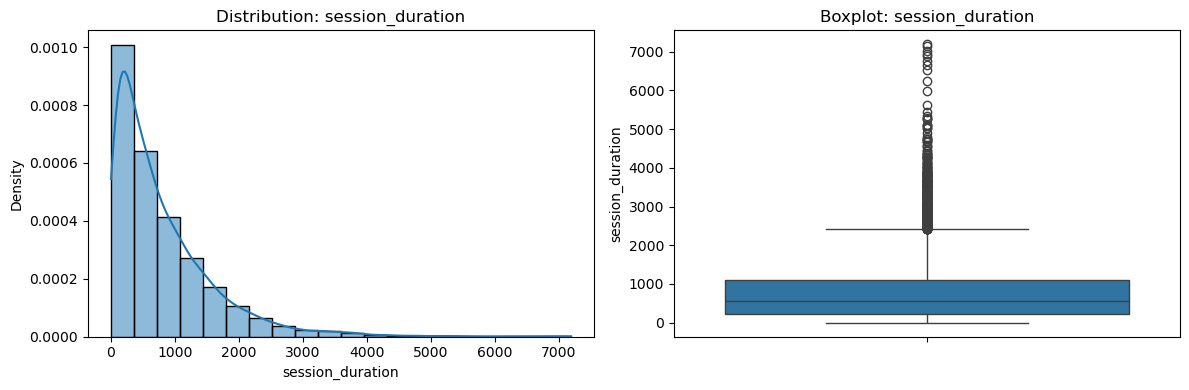

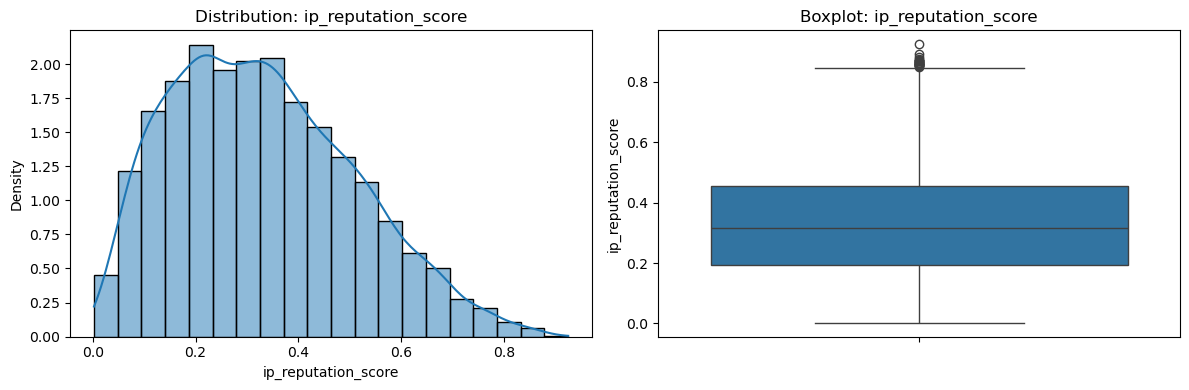

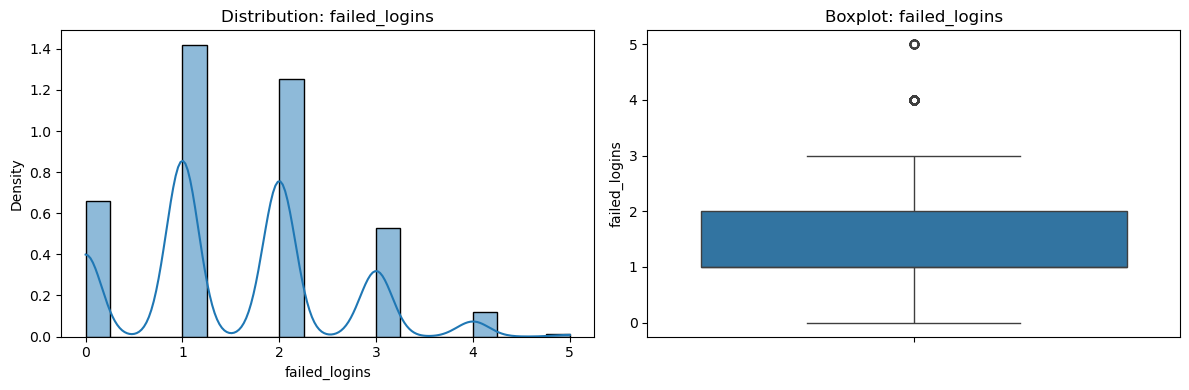

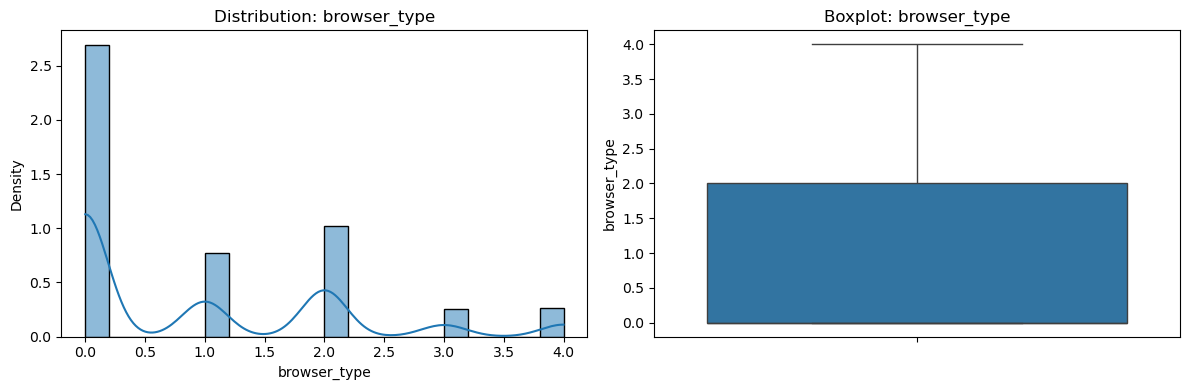

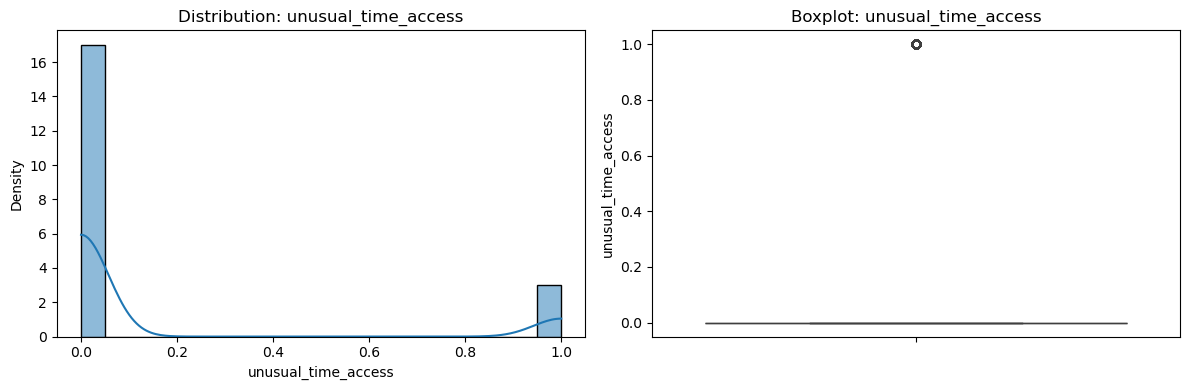

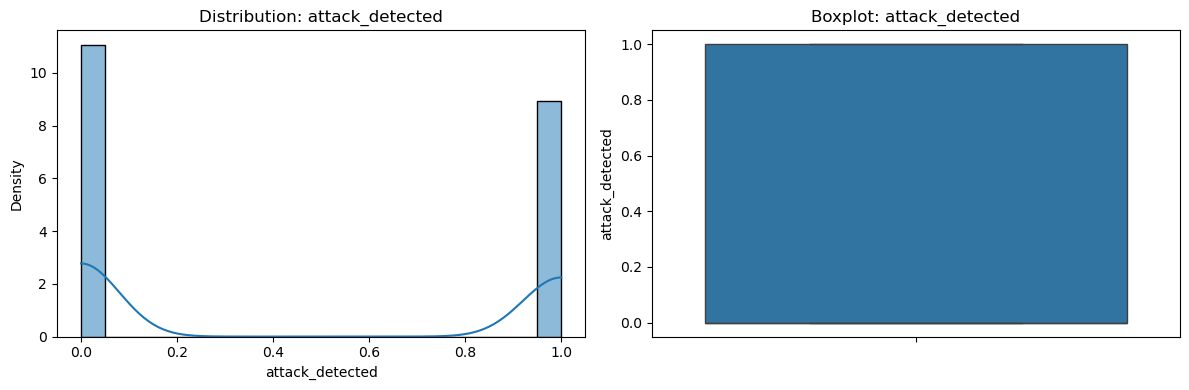

In [30]:
num_cols = df.select_dtypes(include=[np.number]).columns
for column in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[column], kde=True, stat='density', bins=20, ax=axes[0])
    axes[0].set_title(f'Distribution: {column}')
    sns.boxplot(y=df[column], ax=axes[1])
    axes[1].set_title(f'Boxplot: {column}')
    plt.tight_layout()
    plt.show()

In [31]:
X = df.drop(['attack_detected'], axis=1)
y = df['attack_detected']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

ss = StandardScaler()
X_train_sc = ss.fit_transform(X_train)
X_test_sc  = ss.transform(X_test)

print(f'Train size: {X_train_sc.shape}, Test size: {X_test_sc.shape}')

Train size: (7152, 8), Test size: (2385, 8)


Feature Importance (Mutual Information):
            Feature  MI Score
      failed_logins      0.15
     login_attempts      0.10
ip_reputation_score      0.07
       browser_type      0.01
unusual_time_access      0.01
      protocol_type      0.00
network_packet_size      0.00
   session_duration      0.00


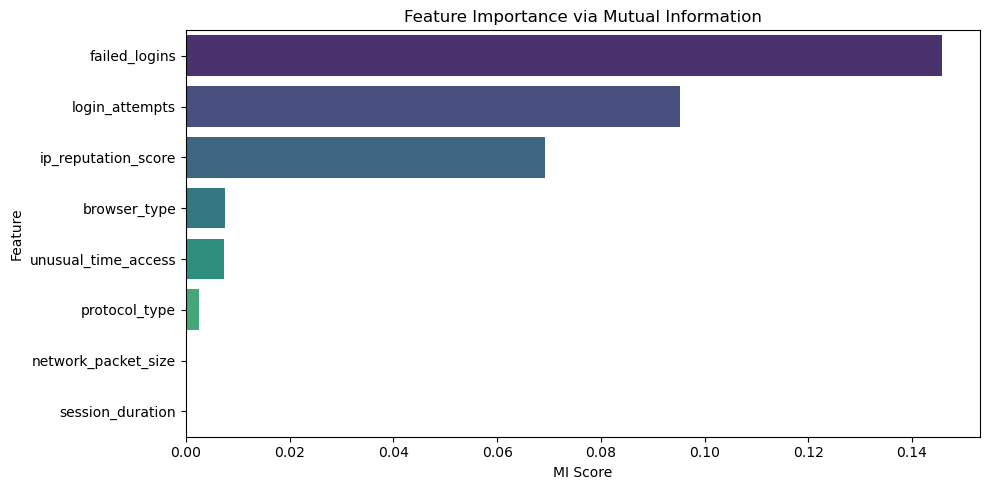


Selected 6 features: ['failed_logins', 'login_attempts', 'ip_reputation_score', 'browser_type', 'unusual_time_access', 'protocol_type']


In [32]:
# ── Mutual Information scores ─────────────────────────────────────────────────
mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train_sc, y_train)

mi_scores = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_selector.scores_
}).sort_values('MI Score', ascending=False).reset_index(drop=True)

print('Feature Importance (Mutual Information):')
print(mi_scores.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=mi_scores, x='MI Score', y='Feature', palette='viridis')
plt.title('Feature Importance via Mutual Information')
plt.tight_layout()
plt.show()

# Select top-K features (keep all that score above 0)
TOP_K = (mi_scores['MI Score'] > 0).sum()
top_features = mi_scores.head(TOP_K)['Feature'].tolist()
print(f'\nSelected {TOP_K} features: {top_features}')

X_train_sel = X_train_sc[:, mi_scores.index[:TOP_K]]
X_test_sel  = X_test_sc[:,  mi_scores.index[:TOP_K]]

In [33]:
xgb_param_grid = {
    'n_estimators':   [100, 200, 300],
    'max_depth':      [3, 5, 7],
    'learning_rate':  [0.01, 0.05, 0.1, 0.2],
    'subsample':      [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_base = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_search.fit(X_train_sel, y_train)

print(f'Best params : {xgb_search.best_params_}')
print(f'Best CV F1  : {xgb_search.best_score_:.4f}')

best_xgb = xgb_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params : {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV F1  : 0.8363


In [34]:
# ── Base estimators ───────────────────────────────────────────────────────────
base_estimators = [
    ('rf',  RandomForestClassifier(n_estimators=200, random_state=42)),
    ('xgb', best_xgb),
    ('gb',  GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('dt',  DecisionTreeClassifier(max_depth=8, random_state=42)),
]

# ── Stacking Classifier (proposed framework) ──────────────────────────────────
stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    passthrough=False,
    n_jobs=-1
)

# ── Soft-Voting Ensemble ──────────────────────────────────────────────────────
voting_clf = VotingClassifier(
    estimators=base_estimators,
    voting='soft',
    n_jobs=-1
)

stacking_clf.fit(X_train_sel, y_train)
voting_clf.fit(X_train_sel, y_train)

print('Ensemble models trained.')

[14:46:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:46:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:46:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.
[14:46:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


[14:46:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Ensemble models trained.


In [35]:
all_models = {
    'Random Forest':            RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=10, min_samples_leaf=5, max_features='sqrt', random_state=42),
    'Decision Tree':            DecisionTreeClassifier(max_depth=8, random_state=42),
    'AdaBoost':                 AdaBoostClassifier(random_state=42),
    'Logistic Regression':      LogisticRegression(max_iter=1000, random_state=42),
    'Gradient Boosting':        GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Naive Bayes':              GaussianNB(),
    'XGBoost':                  best_xgb,
    'Stacking Ensemble':        stacking_clf,
    'Voting Ensemble':          voting_clf,
}

results = []

for name, model in all_models.items():
    if name not in ('XGBoost (Tuned)', 'Stacking Ensemble (Proposed)', 'Voting Ensemble'):
        model.fit(X_train_sel, y_train)

    # ── Training metrics ──────────────────────────────────────────────────────
    y_train_pred  = model.predict(X_train_sel)
    y_train_proba = model.predict_proba(X_train_sel)[:, 1]

    train_acc    = accuracy_score(y_train, y_train_pred)
    train_f1     = f1_score(y_train, y_train_pred)
    train_prec   = precision_score(y_train, y_train_pred)
    train_rec    = recall_score(y_train, y_train_pred)
    train_auc    = roc_auc_score(y_train, y_train_proba)

    # ── Test metrics ──────────────────────────────────────────────────────────
    y_pred  = model.predict(X_test_sel)
    y_proba = model.predict_proba(X_test_sel)[:, 1]

    test_acc    = accuracy_score(y_test, y_pred)
    test_f1     = f1_score(y_test, y_pred)
    test_prec   = precision_score(y_test, y_pred)
    test_rec    = recall_score(y_test, y_pred)
    test_auc    = roc_auc_score(y_test, y_proba)

    cv_scores = cross_val_score(model, X_train_sel, y_train, cv=5, scoring='f1', n_jobs=-1)

    results.append({
        'Model':           name,
        # Train
        'Train Accuracy':  round(train_acc * 100, 2),
        'Train F1':        round(train_f1 * 100, 2),
        'Train Precision': round(train_prec * 100, 2),
        'Train Recall':    round(train_rec * 100, 2),
        'Train ROC-AUC':   round(train_auc * 100, 2),
        # Test
        'Test Accuracy':   round(test_acc * 100, 2),
        'Test F1':         round(test_f1 * 100, 2),
        'Test Precision':  round(test_prec * 100, 2),
        'Test Recall':     round(test_rec * 100, 2),
        'Test ROC-AUC':    round(test_auc * 100, 2),
        # CV
        'CV F1 Mean':      round(cv_scores.mean() * 100, 2),
        'CV F1 Std':       round(cv_scores.std() * 100, 2),
    })

    print(f'\n=== {name} ===')
    print(f'  [Train] Acc: {train_acc*100:.2f}%  F1: {train_f1*100:.2f}%  Prec: {train_prec*100:.2f}%  Rec: {train_rec*100:.2f}%  AUC: {train_auc*100:.2f}%')
    print(f'  [Test]  Acc: {test_acc*100:.2f}%  F1: {test_f1*100:.2f}%  Prec: {test_prec*100:.2f}%  Rec: {test_rec*100:.2f}%  AUC: {test_auc*100:.2f}%')
    print(f'  [CV]    F1 Mean: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
    print(classification_report(y_test, y_pred, target_names=['No Attack', 'Attack']))

results_df = pd.DataFrame(results).sort_values('Test ROC-AUC', ascending=False).reset_index(drop=True)
print('\n── Summary Table ──')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)

print(results_df.to_string(index=False))


=== Random Forest ===
  [Train] Acc: 87.70%  F1: 84.05%  Prec: 100.00%  Rec: 72.48%  AUC: 98.55%
  [Test]  Acc: 86.37%  F1: 82.03%  Prec: 99.87%  Rec: 69.61%  AUC: 85.89%
  [CV]    F1 Mean: 83.56% ± 1.21%
              precision    recall  f1-score   support

   No Attack       0.80      1.00      0.89      1319
      Attack       1.00      0.70      0.82      1066

    accuracy                           0.86      2385
   macro avg       0.90      0.85      0.86      2385
weighted avg       0.89      0.86      0.86      2385


=== Decision Tree ===
  [Train] Acc: 87.92%  F1: 84.46%  Prec: 99.41%  Rec: 73.42%  AUC: 89.08%
  [Test]  Acc: 85.91%  F1: 81.56%  Prec: 98.28%  Rec: 69.70%  AUC: 85.74%
  [CV]    F1 Mean: 83.27% ± 0.94%
              precision    recall  f1-score   support

   No Attack       0.80      0.99      0.89      1319
      Attack       0.98      0.70      0.82      1066

    accuracy                           0.86      2385
   macro avg       0.89      0.84      0.85 

[14:46:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:46:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:46:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:46:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:46:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:46:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:46:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:46:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" }


=== Stacking Ensemble ===
  [Train] Acc: 88.72%  F1: 85.58%  Prec: 99.83%  Rec: 74.89%  AUC: 99.63%
  [Test]  Acc: 86.16%  F1: 81.87%  Prec: 98.81%  Rec: 69.89%  AUC: 85.96%
  [CV]    F1 Mean: 83.36% ± 1.17%
              precision    recall  f1-score   support

   No Attack       0.80      0.99      0.89      1319
      Attack       0.99      0.70      0.82      1066

    accuracy                           0.86      2385
   macro avg       0.90      0.85      0.85      2385
weighted avg       0.89      0.86      0.86      2385



[14:46:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:46:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:46:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:46:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:46:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




=== Voting Ensemble ===
  [Train] Acc: 88.12%  F1: 84.67%  Prec: 100.00%  Rec: 73.42%  AUC: 99.93%
  [Test]  Acc: 86.33%  F1: 81.99%  Prec: 99.73%  Rec: 69.61%  AUC: 85.89%
  [CV]    F1 Mean: 83.54% ± 1.12%
              precision    recall  f1-score   support

   No Attack       0.80      1.00      0.89      1319
      Attack       1.00      0.70      0.82      1066

    accuracy                           0.86      2385
   macro avg       0.90      0.85      0.85      2385
weighted avg       0.89      0.86      0.86      2385


── Summary Table ──
              Model  Train Accuracy  Train F1  Train Precision  Train Recall  Train ROC-AUC  Test Accuracy  Test F1  Test Precision  Test Recall  Test ROC-AUC  CV F1 Mean  CV F1 Std
  Stacking Ensemble           88.72     85.58            99.83         74.89          99.63          86.16    81.87           98.81        69.89         85.96       83.36       1.17
      Random Forest           87.70     84.05           100.00         72.48    

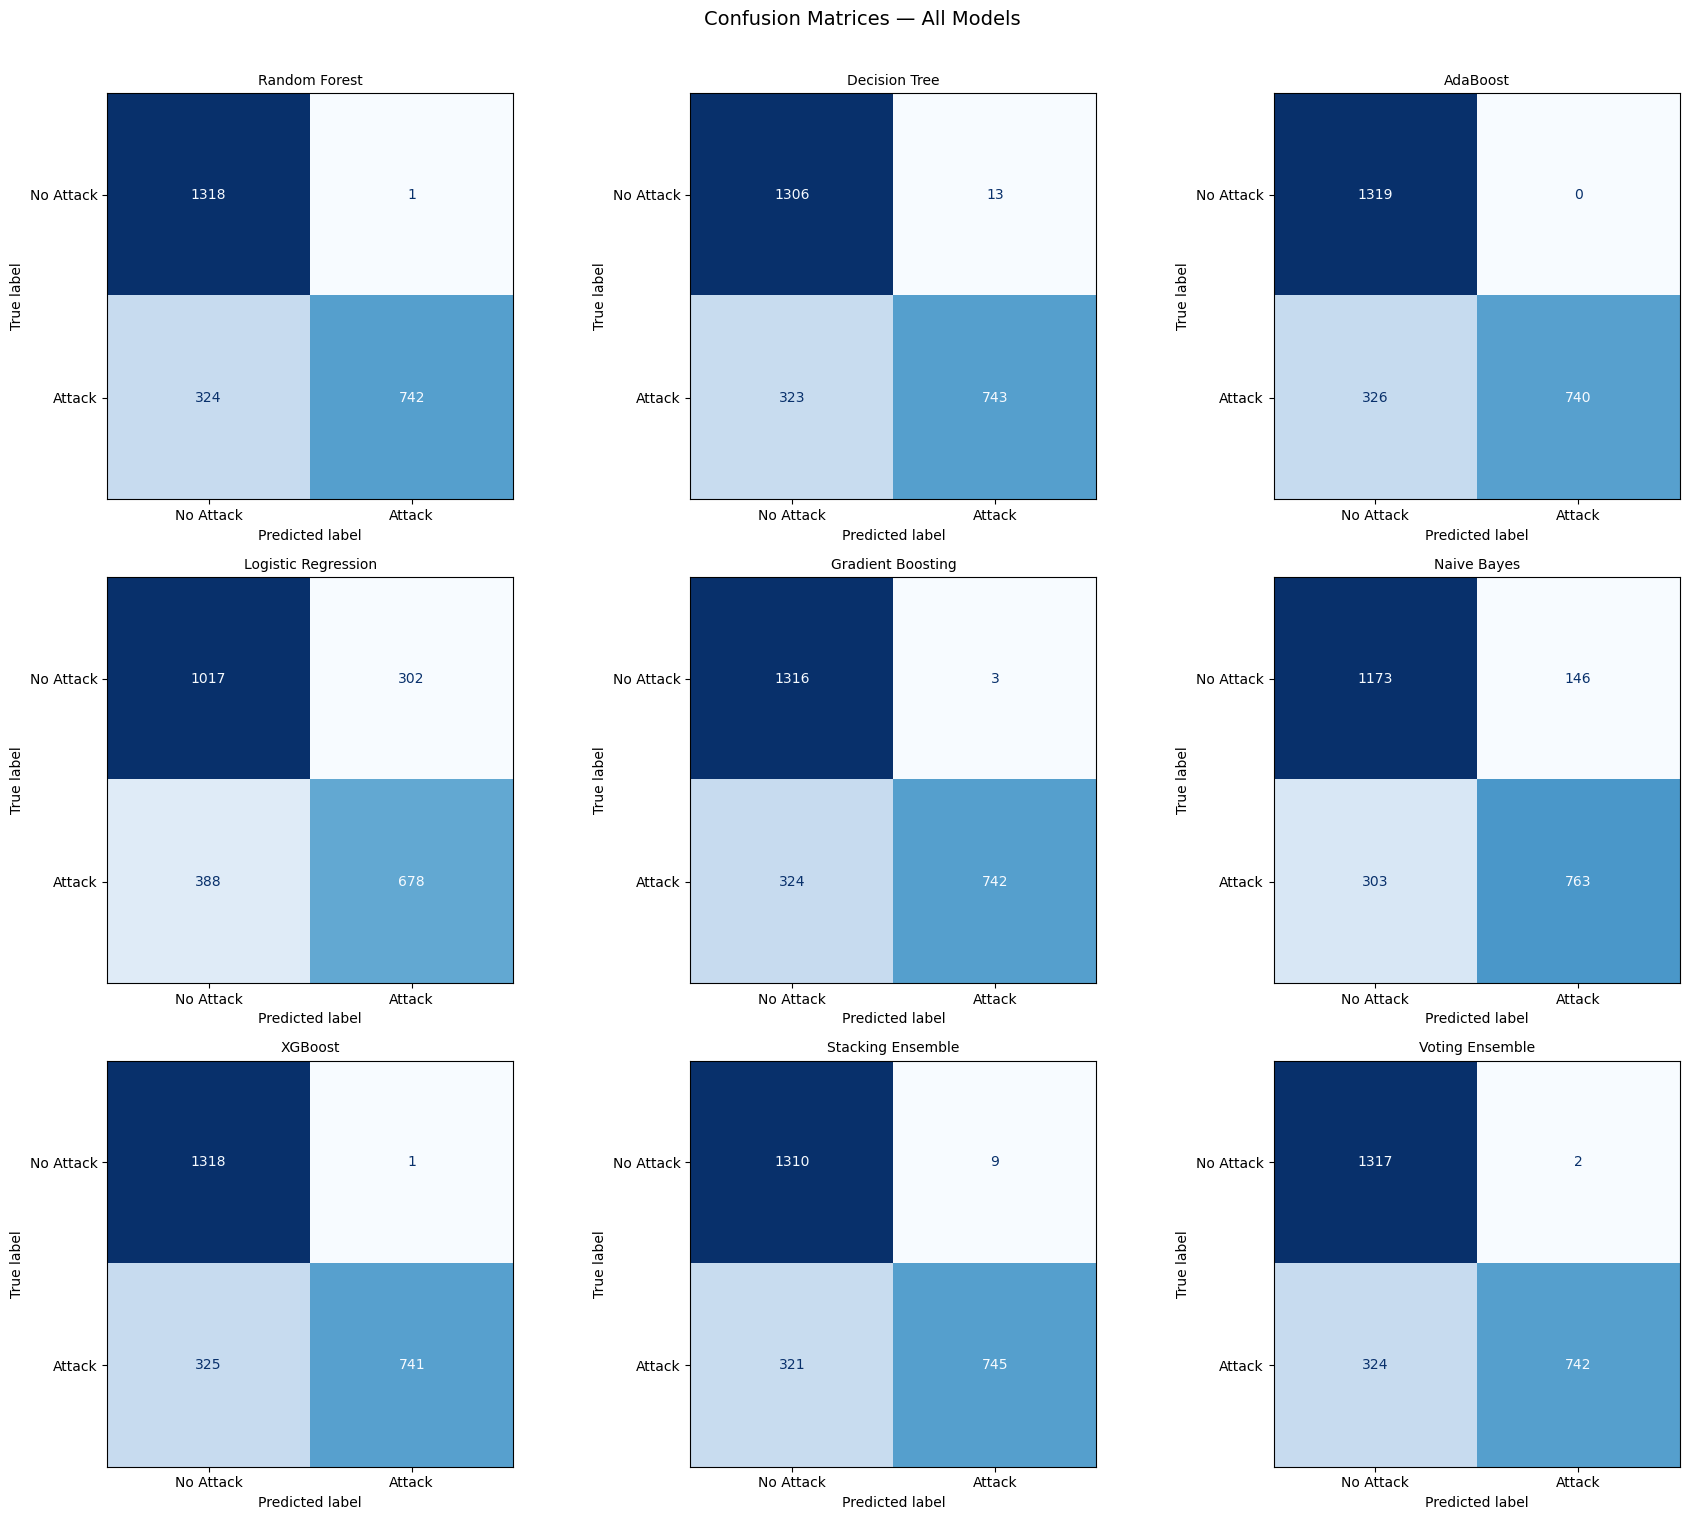

In [36]:
n_models = len(all_models)
n_cols = 3
n_rows = -(-n_models // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for idx, (name, model) in enumerate(all_models.items()):
    y_pred = model.predict(X_test_sel)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Attack', 'Attack'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name, fontsize=10)

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

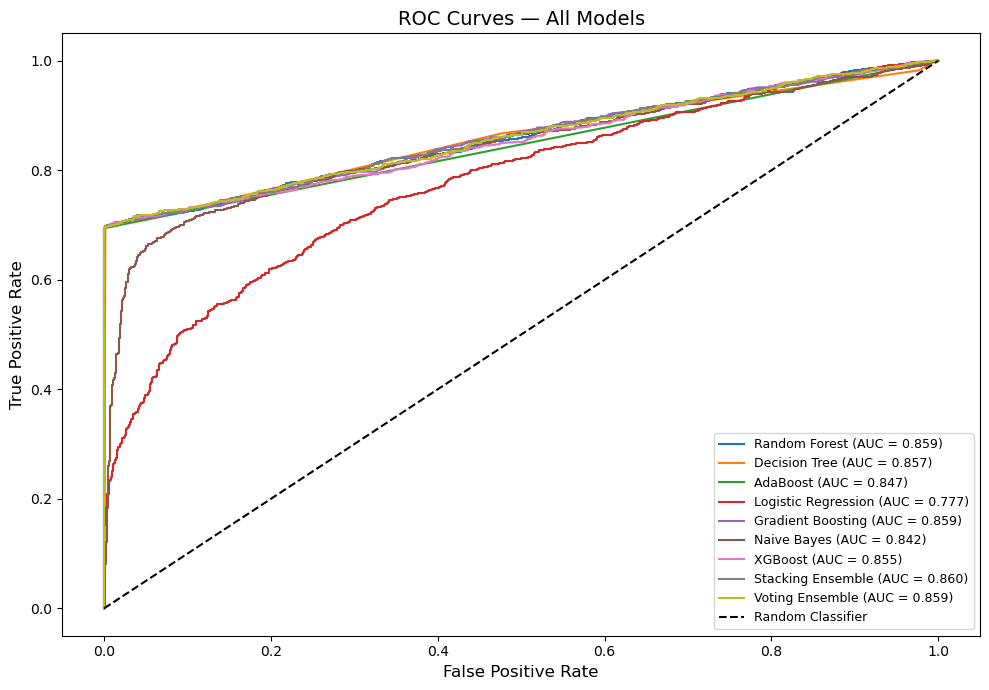

In [37]:
plt.figure(figsize=(10, 7))

for name, model in all_models.items():
    y_proba = model.predict_proba(X_test_sel)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

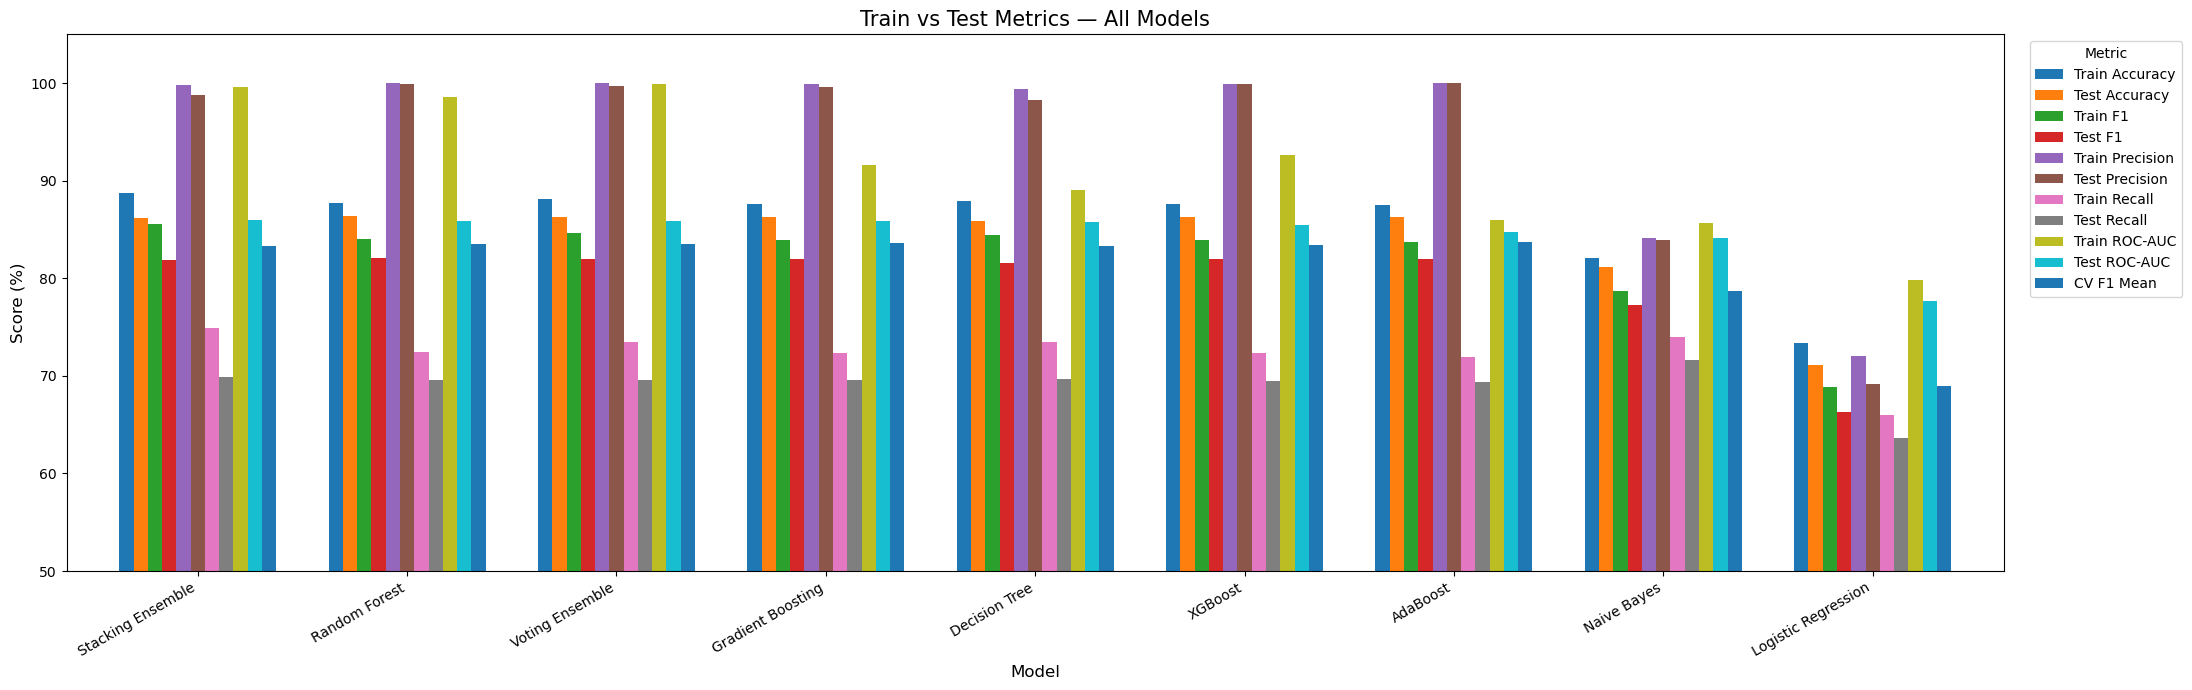

In [38]:
metrics_to_plot = ['Train Accuracy', 'Test Accuracy', 'Train F1', 'Test F1',
                   'Train Precision', 'Test Precision', 'Train Recall', 'Test Recall',
                   'Train ROC-AUC', 'Test ROC-AUC', 'CV F1 Mean']

plot_df = results_df.set_index('Model')[metrics_to_plot]

ax = plot_df.plot(kind='bar', figsize=(22, 7), width=0.75)
plt.title('Train vs Test Metrics — All Models', fontsize=15)
plt.ylabel('Score (%)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.ylim(50, 105)
plt.legend(title='Metric', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

Saved: summary_table.csv
Saved: summary_table.xlsx


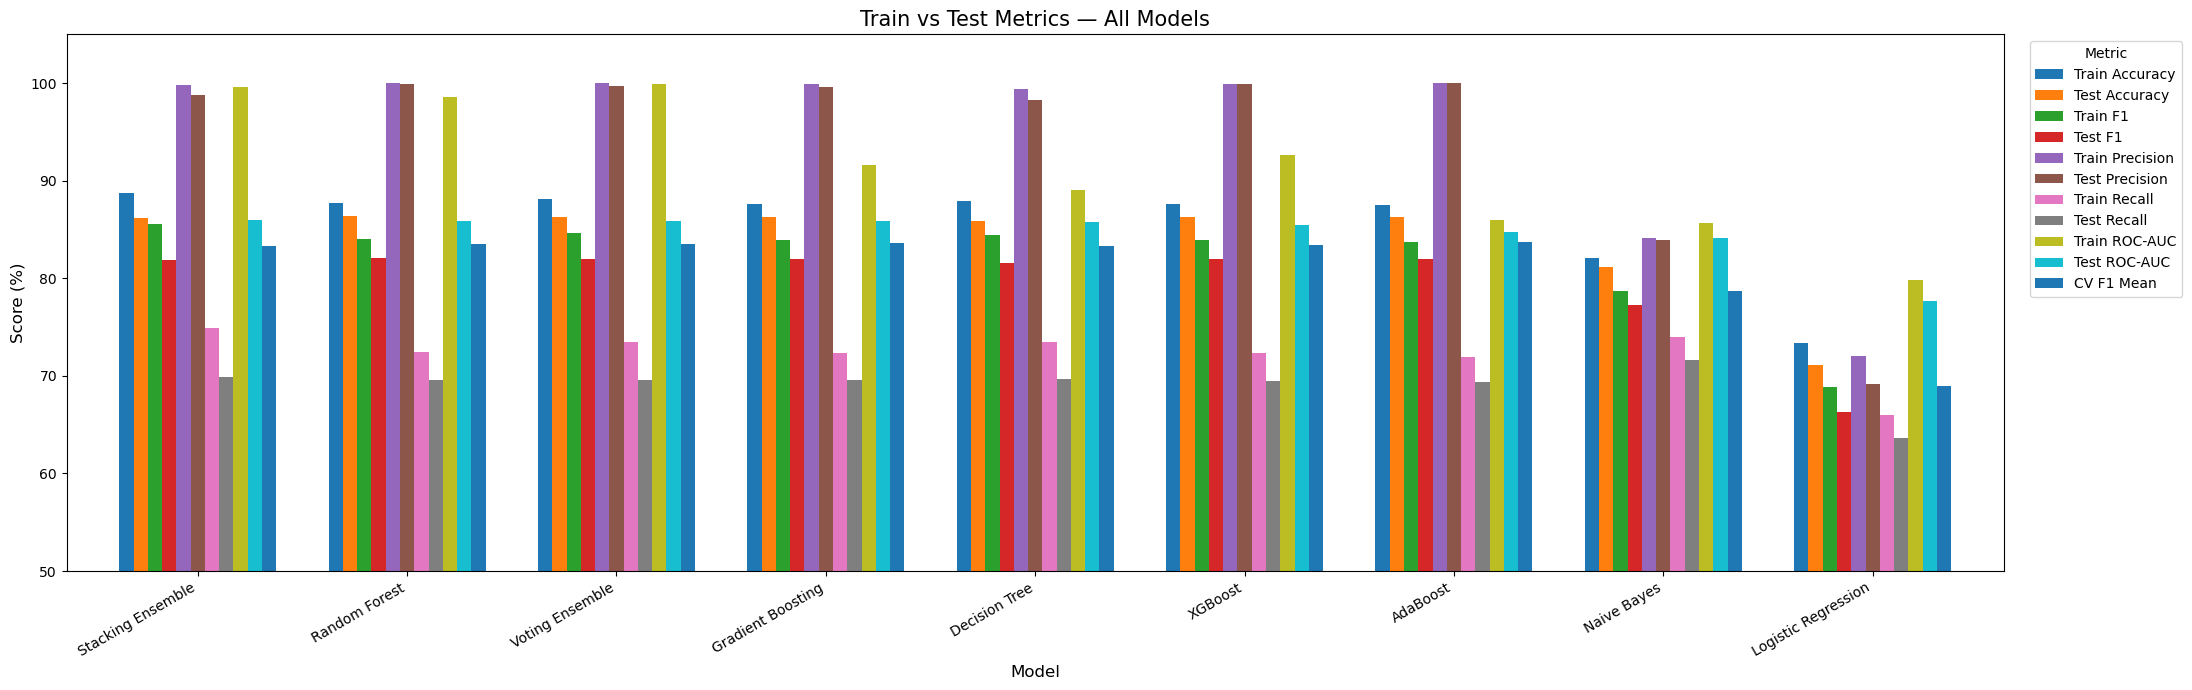

Saved: train_vs_test_metrics.png


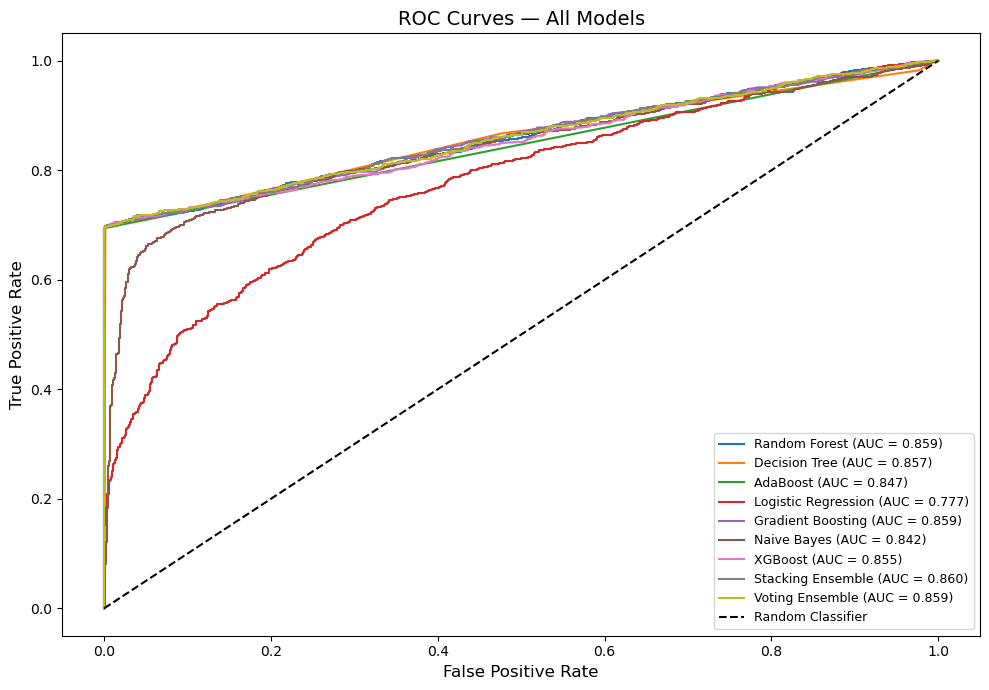

Saved: roc_curves.png


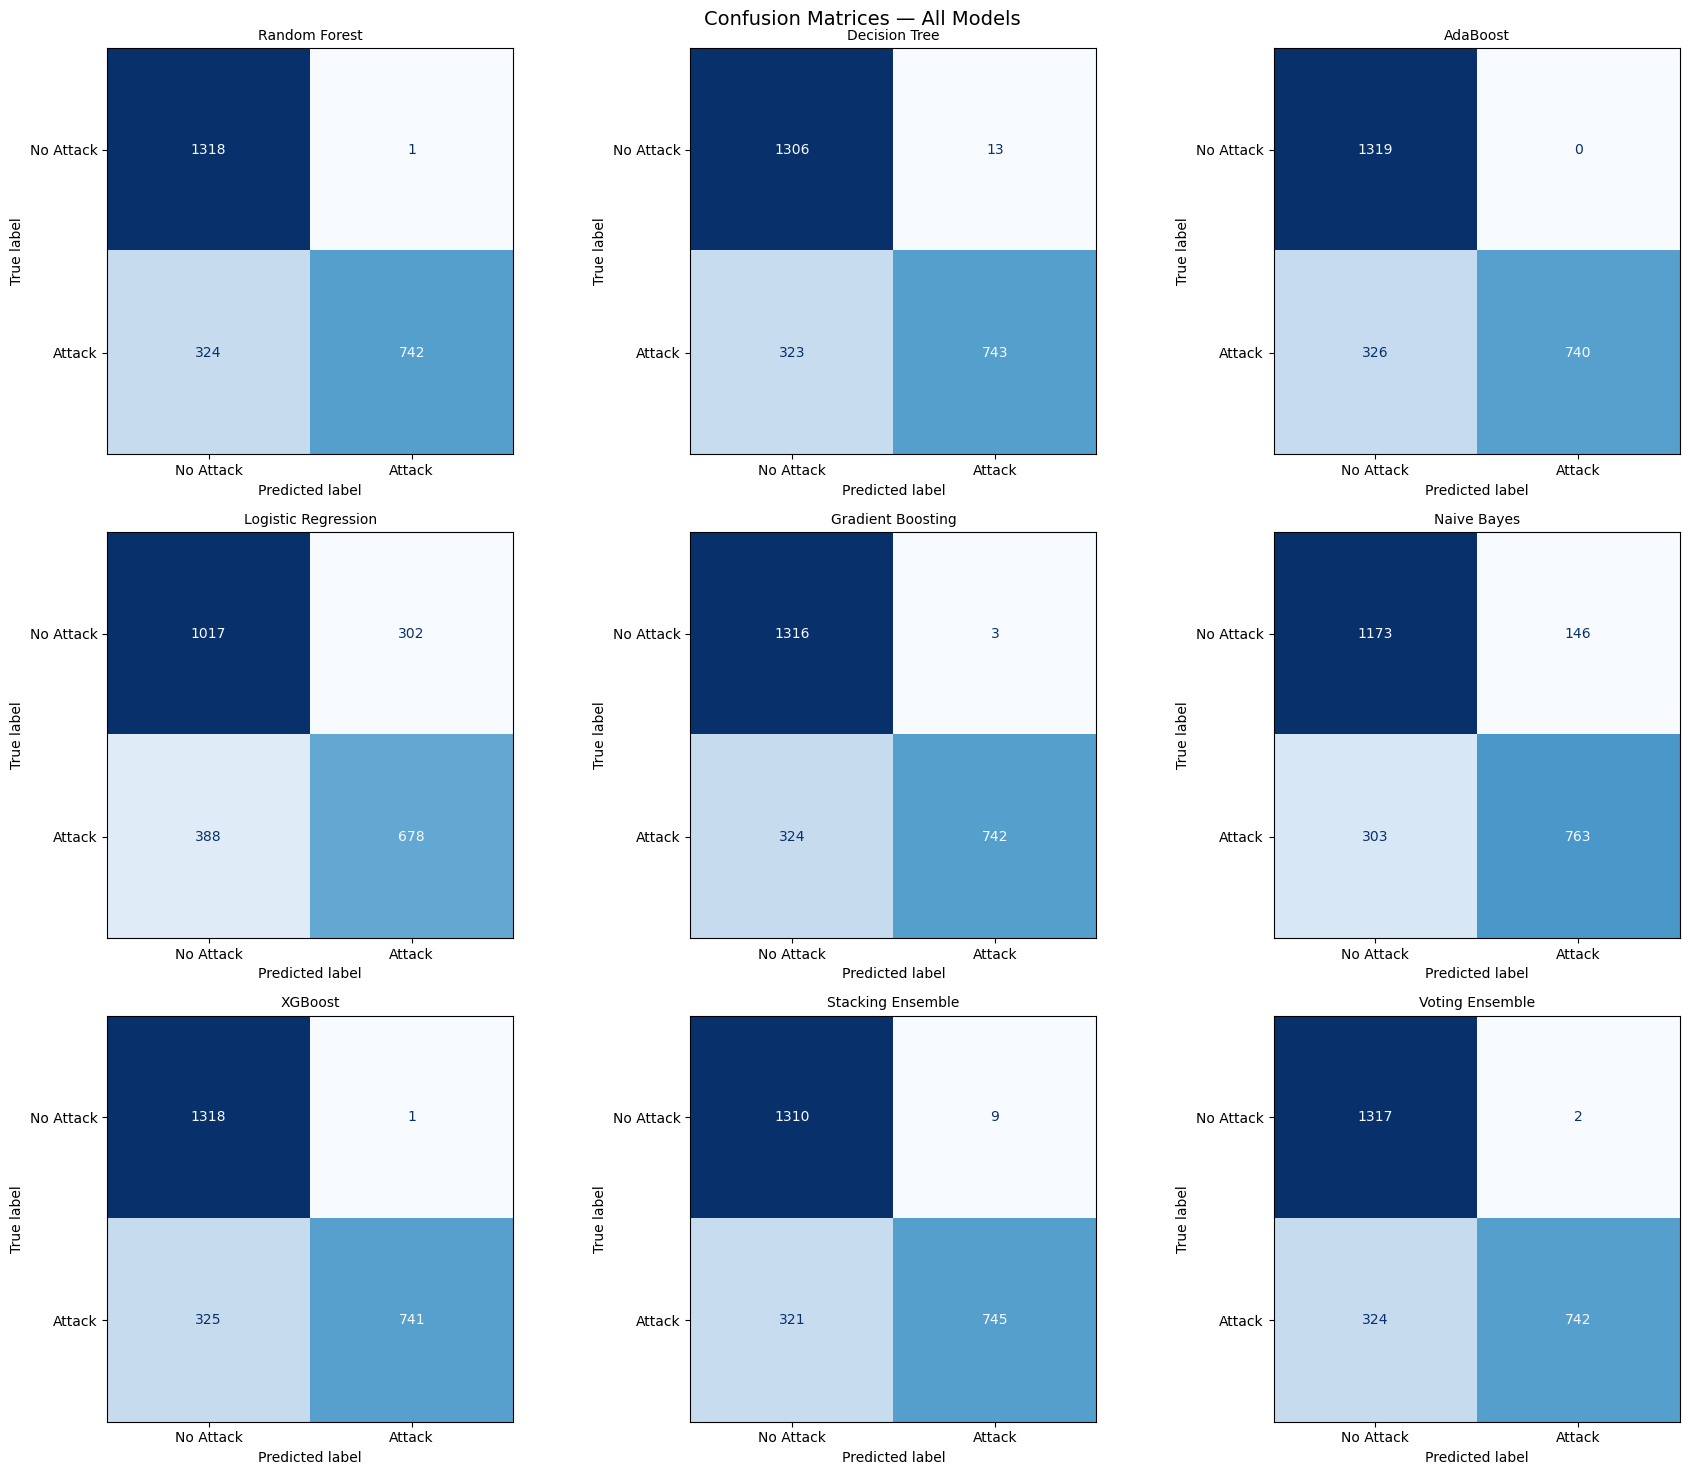

Saved: confusion_matrices.png


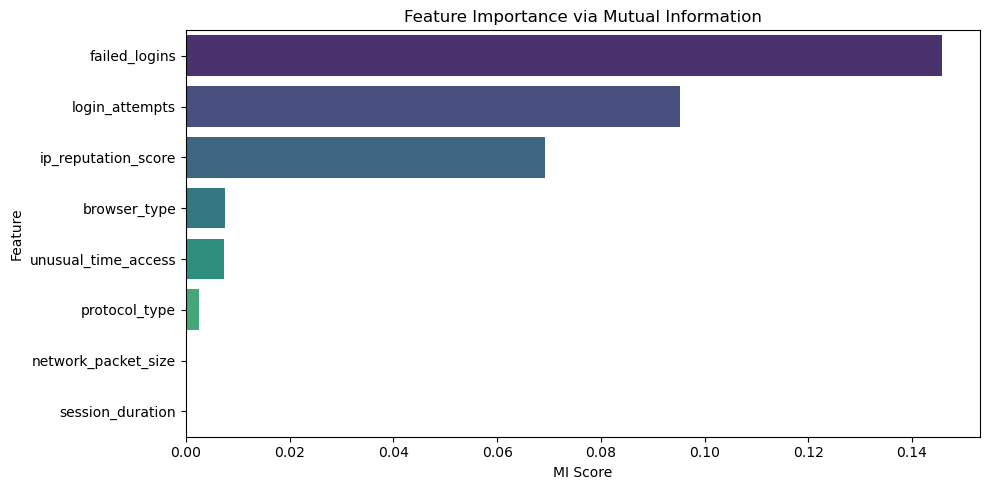

Saved: feature_importance.png

All files saved to: /Users/ahanamahapatra/Anaconda/ML_Project/results_export


In [39]:
import os

out_dir = 'results_export'
os.makedirs(out_dir, exist_ok=True)

# ── 1. Save summary table as CSV ──────────────────────────────────────────────
results_df.to_csv(f'{out_dir}/summary_table.csv', index=False)
print('Saved: summary_table.csv')

# ── 2. Save summary table as Excel ───────────────────────────────────────────
results_df.to_excel(f'{out_dir}/summary_table.xlsx', index=False)
print('Saved: summary_table.xlsx')

# ── 3. Train vs Test bar chart ────────────────────────────────────────────────
metrics_to_plot = ['Train Accuracy', 'Test Accuracy', 'Train F1', 'Test F1',
                   'Train Precision', 'Test Precision', 'Train Recall', 'Test Recall',
                   'Train ROC-AUC', 'Test ROC-AUC', 'CV F1 Mean']
plot_df = results_df.set_index('Model')[metrics_to_plot]
ax = plot_df.plot(kind='bar', figsize=(22, 7), width=0.75)
plt.title('Train vs Test Metrics — All Models', fontsize=15)
plt.ylabel('Score (%)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.ylim(50, 105)
plt.legend(title='Metric', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{out_dir}/train_vs_test_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: train_vs_test_metrics.png')

# ── 4. ROC curves ─────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
for name, model in all_models.items():
    y_proba = model.predict_proba(X_test_sel)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{out_dir}/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

# ── 5. Confusion matrices ─────────────────────────────────────────────────────
n_models = len(all_models)
n_cols = 3
n_rows = -(-n_models // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()
for idx, (name, model) in enumerate(all_models.items()):
    y_pred = model.predict(X_test_sel)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Attack', 'Attack'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name, fontsize=10)
for ax in axes[n_models:]:
    ax.set_visible(False)
plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.savefig(f'{out_dir}/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

# ── 6. Feature importance ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
sns.barplot(data=mi_scores, x='MI Score', y='Feature', palette='viridis')
plt.title('Feature Importance via Mutual Information')
plt.tight_layout()
plt.savefig(f'{out_dir}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

print(f'\nAll files saved to: {os.path.abspath(out_dir)}')